<a href="https://colab.research.google.com/github/Chevlierouge/FDS/blob/master/vision_transformer_from_scratch_with_tfc972f412de.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

2025-09-03 14:14:12.010169: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756908852.187356      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756908852.250432      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# PatchEmbedding

In [ ]:
class PatchEmbedding(tf.keras.layers.Layer):
  def __init__(self , size , num_of_patches , projection_dim):
    super().__init__()

    self.size=size
    self.num_of_patches= num_of_patches + 1
    self.projection_dim=projection_dim

    self.projection=tf.keras.layers.Dense(projection_dim)

    self.clsToken= tf.Variable(tf.keras.initializers.GlorotNormal()(shape=(1 , 1 , projection_dim)) , trainable=True)
    #create vector for each patch
    self.positionalEmbedding = tf.keras.layers.Embedding(self.num_of_patches , projection_dim)


  def call(self, inputs):
    patches = tf.image.extract_patches(inputs , sizes=[1 , self.size , self.size , 1], strides=[1 , self.size , self.size , 1], rates=[1 ,1 ,1 ,1], padding="VALID",)
    patches=tf.reshape(patches, (tf.shape(inputs)[0], -1, self.size * self.size *3))
    patches= self.projection(patches)

    # repeat cls token length of batch size
    clsToken = tf.repeat(self.clsToken , tf.shape(inputs)[0] , 0)
    patches = tf.concat((clsToken, patches) , axis=1)
    # create position number for each patch
    positions = tf.range(0 , self.num_of_patches , 1)[tf.newaxis , ...]
    positionalEmbedding = self.positionalEmbedding(positions)

    #print(positionalEmbedding)
    patches= patches + positionalEmbedding
    return patches

# Transformer Layer





In [ ]:
class TransformerLayer(tf.keras.layers.Layer):
  def __init__(self , d_model , heads , mlp_rate , dropout_rate=0.1):
    super().__init__()

    self.layernorm_1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
    self.mha= tf.keras.layers.MultiHeadAttention(heads, d_model//heads , dropout=dropout_rate)

    self.layernorm_2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
    self.mlp = tf.keras.Sequential([
                                    tf.keras.layers.Dense(d_model * mlp_rate , activation="gelu"),
                                    tf.keras.layers.Dropout(dropout_rate),
                                    tf.keras.layers.Dense(d_model , activation="gelu"),
                                    tf.keras.layers.Dropout(dropout_rate)
    ])
  def call(self , inputs , training=True):
    out_1 = self.layernorm_1(inputs)
    out_1 = self.mha(out_1 , out_1 ,training=training)
    out_1 = inputs + out_1

    out_2= self.layernorm_2(out_1)
    out_2=self.mlp(out_2 , training=training)
    out_2 = out_1 + out_2

    return out_2


# Transformer Encoder

In [ ]:
class TransformerEncoder(tf.keras.layers.Layer):
  def __init__(self , d_model , heads , mlp_rate , num_layers=1 , dropout_rate=0.1):
    super().__init__()

    self.encoders = [TransformerLayer(d_model , heads , mlp_rate , dropout_rate) for _ in range(num_layers)]

  def call(self , inputs , training=True):
    x =inputs

    for layer in self.encoders:
      x = layer(x , training=training)

    return x

# Vision Transformer

In [ ]:
class ViT(tf.keras.Model):
  def __init__(self , num_classes , patch_size , num_of_patches , d_model , heads , num_layers , mlp_rate , dropout_rate=0.1):
    super().__init__()

    self.patchEmbedding = PatchEmbedding(patch_size , num_of_patches , d_model)
    self.encoder = TransformerEncoder(d_model , heads , mlp_rate  ,num_layers , dropout_rate)

    self.prediction = tf.keras.Sequential([
                                           tf.keras.layers.Dropout(0.3),
                                           tf.keras.layers.Dense(mlp_rate * d_model , activation="gelu"),
                                           tf.keras.layers.Dropout(0.2),
                                           tf.keras.layers.Dense(num_classes, activation="softmax")


  ])
  def call(self , inputs ,  training=True):
    patches = self.patchEmbedding(inputs)
    encoderResult = self.encoder(patches, training=training)

    clsResult = encoderResult[: , 0 , :]

    prediction = self.prediction(clsResult,
                                 training=training)
    return prediction

# prepare dataset

In [ ]:
num_classes = 100
input_shape = (32, 32, 3)

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar100.load_data()

print(f"x_train shape: {x_train.shape} - y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape} - y_test shape: {y_test.shape}")

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
x_train shape: (50000, 32, 32, 3) - y_train shape: (50000, 1)
x_test shape: (10000, 32, 32, 3) - y_test shape: (10000, 1)


In [ ]:
image_size=72
preprocessingModel = tf.keras.Sequential(
    [
        tf.keras.layers.Normalization(),
        tf.keras.layers.Resizing(image_size, image_size),
    ]
)
# Compute the mean and the variance of the training data for normalization.
preprocessingModel.layers[0].adapt(x_train)

augmentationModel = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(factor=0.02),
        tf.keras.layers.RandomZoom(
            height_factor=0.2, width_factor=0.2
        ),
    ]
)

I0000 00:00:1756908870.460247      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [ ]:
def convert_to_dataset(data, batch_size, shuffle=False , augment=False):
  dataset = tf.data.Dataset.from_tensor_slices(data)
  dataset = dataset.map(lambda x , y: (preprocessingModel(x) [0] , y) , num_parallel_calls=tf.data.AUTOTUNE)

  if shuffle:
    dataset= dataset.shuffle(len(dataset))

  dataset = dataset.batch(batch_size , drop_remainder=True)

  if augment:
    dataset = dataset.map(lambda x , y: (augmentationModel(x , training=True) , y) , num_parallel_calls=tf.data.AUTOTUNE)

  return dataset.prefetch(tf.data.AUTOTUNE)


In [ ]:
trainingData = convert_to_dataset((x_train , y_train) , 1024 , shuffle=True , augment=True)
valData = convert_to_dataset((x_test , y_test) , 1024 , shuffle=False , augment=False)

print(trainingData)
print(valData)

<_PrefetchDataset element_spec=(TensorSpec(shape=(1024, 72, 72, 3), dtype=tf.float32, name=None), TensorSpec(shape=(1024, 1), dtype=tf.int64, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(1024, 72, 72, 3), dtype=tf.float32, name=None), TensorSpec(shape=(1024, 1), dtype=tf.int64, name=None))>


# model

In [ ]:
vitClassifier = ViT(
                num_classes,
                6,
                (72//6)**2,
                128,
                2,
                4,
                2,
                0.1
)

vitClassifier.compile(
  optimizer="adam",
  loss=tf.keras.losses.SparseCategoricalCrossentropy(),
  metrics=[
      tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
      tf.keras.metrics.SparseTopKCategoricalAccuracy(5, name="top-5-accuracy"),
  ],
)

In [ ]:
history = vitClassifier.fit(trainingData , batch_size=1024 , validation_data=valData , epochs=60)

Epoch 1/60
48/48 ━━━━━━━━━━━━━━━━━━━━ 25s 430ms/step - accuracy: 0.8031 - loss: 0.6329 - top-5-accuracy: 0.9746 - val_accuracy: 0.5497 - val_loss: 2.1465 - val_top-5-accuracy: 0.8161
Epoch 2/60
28/48 ━━━━━━━━━━━━━━━━━━━━ 7s 398ms/step - accuracy: 0.8023 - loss: 0.6332 - top-5-accuracy: 0.9735

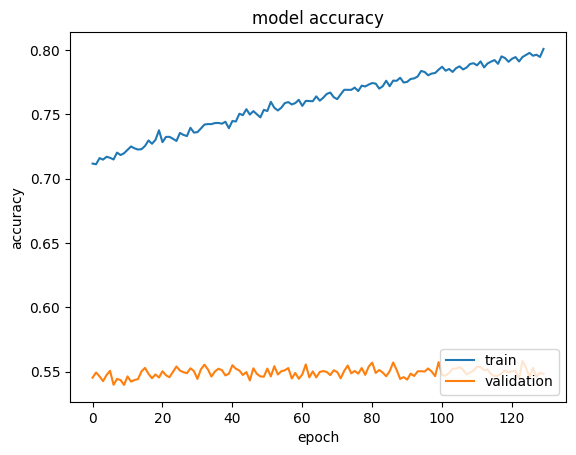

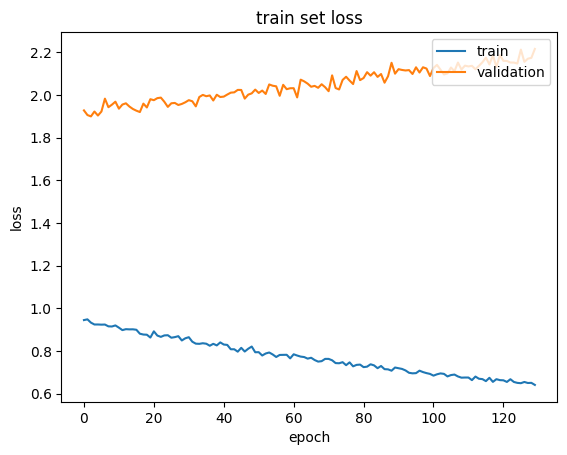

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='lower right')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('train set loss')

plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper right')
plt.show()

# Test

In [ ]:
_, accuracy, top_5_accuracy = vitClassifier.evaluate(valData)
print(f"Test accuracy: {round(accuracy * 100, 2)}%")
print(f"Test top 5 accuracy: {round(top_5_accuracy * 100, 2)}%")

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.5434 - loss: 2.2342 - top-5-accuracy: 0.8153
Test accuracy: 54.83%
Test top 5 accuracy: 81.76%
